<a href="https://colab.research.google.com/github/SrilathaWeb/Data-Science-Cohort-20/blob/main/project-1/project_1_Trasaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 – To Do List



## Problem Definition

1. Write a concise problem definition for the project. Put it in a text field at the top of your Jupyter notebook.



The goal of this project is to build a machine learning model that predicts whether a financial transaction will be successful (target = 1) or unsuccessful (target = 0) based on a set of anonymized predictor variables (var_0 to var_99).

Exploratory data analysis (EDA) to understand the structure and distribution of the data, assess assumptions such as normality and feature independence, and identify any data quality issues.

A Gaussian Naive Bayes classifier be trained and evaluated on this dataset, with performance measured using accuracy, cross-validation, confusion matrix, and classification metrics.

Additionally, investigate the impact of class imbalance by comparing model performance on the original dataset (which is skewed toward unsuccessful transactions) versus a balanced dataset with a 50/50 class distribution.

## Data Collection

2. Load Pandas, Numpy, and Matplotlib.

1. Load data Train.csv from AWS S3.



In [ ]:
# Import libraries
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load data
path = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv"
df = pd.read_csv(path)

# View data
df.head(10)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,train_5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
6,6,train_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,train_7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,train_8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,train_9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail(2)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.169


In [ ]:
df.describe()

,Unnamed: 0,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
count,1.050000e+06,180000.000000,180000.000000,180000.000000,180000.000000,0.0,180000.000000,0.0,0.0,180000.000000,...,0.0,180000.000000,0.0,180000.000000,0.0,0.0,0.0,0.0,0.0,180000.000000
mean,5.249995e+05,0.100222,7.440715,15.870166,12.735619,NaN,-0.668334,NaN,NaN,1.190419,...,NaN,-3.294620,NaN,-6.727860,NaN,NaN,NaN,NaN,NaN,14.224538
std,3.031090e+05,0.300297,3.021636,3.010492,4.185923,NaN,5.968300,NaN,NaN,5.169343,...,NaN,7.418545,NaN,8.278554,NaN,NaN,NaN,NaN,NaN,0.171058
min,0.000000e+00,0.000000,-2.691700,6.299300,-1.018500,NaN,-22.748700,NaN,NaN,-15.194000,...,NaN,-29.984000,NaN,-35.211700,NaN,NaN,NaN,NaN,NaN,13.729000
25%,2.624998e+05,0.000000,5.160325,13.830400,9.664675,NaN,-4.997500,NaN,NaN,-2.571400,...,NaN,-8.757925,NaN,-12.835875,NaN,NaN,NaN,NaN,NaN,14.098900
50%,5.249995e+05,0.000000,7.350950,15.934600,12.670700,NaN,-0.560300,NaN,NaN,1.194600,...,NaN,-3.170950,NaN,-6.615100,NaN,NaN,NaN,NaN,NaN,14.226800
75%,7.874992e+05,0.000000,9.511125,18.061425,15.837300,NaN,3.632525,NaN,NaN,5.090450,...,NaN,2.043350,NaN,-0.885250,NaN,NaN,NaN,NaN,NaN,14.361800
max,1.049999e+06,1.000000,16.716500,26.079100,26.997600,NaN,18.855400,NaN,NaN,18.471400,...,NaN,21.236400,NaN,18.105600,NaN,NaN,NaN,NaN,NaN,14.743000


## Data Cleaning

4. Examine the data using tools we have used in class.

1. If there are data cleaning issues, develop recommendations for how to deal with them.



In [ ]:
# Shape of dataset
df.shape

(1050000, 104)

In [ ]:
# Data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [ ]:

# Check missing values
df.isnull().sum()


,0
Unnamed: 0,0
ID_code,0
target,870000
var_0,870000
var_1,870000
...,...
var_96,1050000
var_97,1050000
var_98,1050000
var_99,1050000


In [ ]:
# Summary statistics
df.describe()

,Unnamed: 0,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
count,1.050000e+06,180000.000000,180000.000000,180000.000000,180000.000000,0.0,180000.000000,0.0,0.0,180000.000000,...,0.0,180000.000000,0.0,180000.000000,0.0,0.0,0.0,0.0,0.0,180000.000000
mean,5.249995e+05,0.100222,7.440715,15.870166,12.735619,NaN,-0.668334,NaN,NaN,1.190419,...,NaN,-3.294620,NaN,-6.727860,NaN,NaN,NaN,NaN,NaN,14.224538
std,3.031090e+05,0.300297,3.021636,3.010492,4.185923,NaN,5.968300,NaN,NaN,5.169343,...,NaN,7.418545,NaN,8.278554,NaN,NaN,NaN,NaN,NaN,0.171058
min,0.000000e+00,0.000000,-2.691700,6.299300,-1.018500,NaN,-22.748700,NaN,NaN,-15.194000,...,NaN,-29.984000,NaN,-35.211700,NaN,NaN,NaN,NaN,NaN,13.729000
25%,2.624998e+05,0.000000,5.160325,13.830400,9.664675,NaN,-4.997500,NaN,NaN,-2.571400,...,NaN,-8.757925,NaN,-12.835875,NaN,NaN,NaN,NaN,NaN,14.098900
50%,5.249995e+05,0.000000,7.350950,15.934600,12.670700,NaN,-0.560300,NaN,NaN,1.194600,...,NaN,-3.170950,NaN,-6.615100,NaN,NaN,NaN,NaN,NaN,14.226800
75%,7.874992e+05,0.000000,9.511125,18.061425,15.837300,NaN,3.632525,NaN,NaN,5.090450,...,NaN,2.043350,NaN,-0.885250,NaN,NaN,NaN,NaN,NaN,14.361800
max,1.049999e+06,1.000000,16.716500,26.079100,26.997600,NaN,18.855400,NaN,NaN,18.471400,...,NaN,21.236400,NaN,18.105600,NaN,NaN,NaN,NaN,NaN,14.743000


In [ ]:
nunique = df.nunique().sort_values(ascending=False)
nunique

,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137280
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


In [ ]:
df_copy = df.copy()

In [ ]:
drop_ids = nunique[nunique==df.shape[0] ].index
drop_ids


Index(['Unnamed: 0', 'ID_code'], dtype='object')

In [ ]:
df.drop(columns=drop_ids, inplace=True)
df.head()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.476,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df["target"].value_counts( dropna= False)

,count
target,
NaN,870000
0.0,161960
1.0,18040


In [ ]:
df.dropna(subset=["target"], inplace=True)
df.head(2)

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.4760,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,-6.4882,6.0821,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520


In [ ]:
df["target"].isna().sum()

np.int64(0)

In [ ]:
df = df.dropna(axis=1, how='all')

In [ ]:
dataframe_duplicates = df[df.duplicated()]
dataframe_duplicates

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100


## Exploratory Data Analysis

6. Produce some visual analysis of the data – like plots showing the distributions of all variables. Recall that Gaussian Naive Bayes assumes the predictors are normally distributed. Note: you might have to do multiple plots in groups.

1. NOTE: the ‘target’ column indicates a successful transaction (‘1’) or a no-transaction (‘0’). Verify these are the only values in that column.

1. Check the correlation values between all **predictor columns** to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.

1. Create two data frames: one with all successful transactions, one with all unsuccessful transactions. **Make sure they are copies and not slices**.





In [ ]:
df["target"].value_counts( dropna= False)

,count
target,
0.0,161960
1.0,18040


In [ ]:
corr = df.corr()
corr

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
target,1.000000,0.045506,-0.051718,-0.046433,0.041593,-0.041987,0.052457,0.045281,-0.057373,-0.054375,...,-0.052324,-0.053733,-0.042073,0.047543,-0.063871,-0.042765,0.059306,0.040520,0.049072,-0.047005
var_0,0.045506,1.000000,-0.000892,-0.000225,-0.000269,-0.001320,0.002949,0.002901,-0.007758,-0.002799,...,-0.004960,-0.005451,-0.000716,0.004577,-0.004664,-0.001088,0.000236,0.001668,0.001837,0.001475
var_1,-0.051718,-0.000892,1.000000,0.006064,-0.000821,0.000783,-0.007127,-0.006180,-0.002585,-0.001663,...,0.004265,0.002411,0.001484,-0.003859,-0.000485,0.003141,-0.006188,0.000071,-0.003682,0.003964
var_2,-0.046433,-0.000225,0.006064,1.000000,-0.003427,-0.000108,-0.001809,-0.002786,-0.001177,0.006360,...,0.004890,0.002240,0.001980,-0.001161,0.003921,0.002087,-0.004422,-0.003418,-0.001565,0.002418
var_4,0.041593,-0.000269,-0.000821,-0.003427,1.000000,-0.002750,0.003347,0.001377,-0.004732,-0.001814,...,0.000657,-0.005267,-0.004266,-0.004179,-0.004211,-0.002330,0.000254,0.001090,-0.000468,-0.002807
var_7,-0.041987,-0.001320,0.000783,-0.000108,-0.002750,1.000000,-0.003199,-0.003588,0.002329,0.004282,...,-0.000412,0.003262,0.002574,-0.001824,0.001186,0.002811,0.001306,0.000236,-0.000568,0.004575
var_8,0.052457,0.002949,-0.007127,-0.001809,0.003347,-0.003199,1.000000,0.003472,-0.003858,-0.002727,...,-0.008394,-0.004254,-0.002446,0.001117,-0.003713,-0.003929,0.003837,0.003422,0.003204,0.000821
var_14,0.045281,0.002901,-0.006180,-0.002786,0.001377,-0.003588,0.003472,1.000000,-0.007115,-0.004249,...,-0.002214,-0.002179,-0.003054,-0.000160,-0.000504,-0.004046,0.003136,0.005715,0.001501,-0.000106
var_15,-0.057373,-0.007758,-0.002585,-0.001177,-0.004732,0.002329,-0.003858,-0.007115,1.000000,0.002467,...,0.000581,0.006633,0.004569,-0.001573,0.003251,0.003066,-0.001541,-0.003719,-0.002825,0.004247
var_17,-0.054375,-0.002799,-0.001663,0.006360,-0.001814,0.004282,-0.002727,-0.004249,0.002467,1.000000,...,0.005578,0.001237,0.000210,-0.002714,0.004149,-0.002182,-0.002642,-0.001968,-0.004100,-0.000822


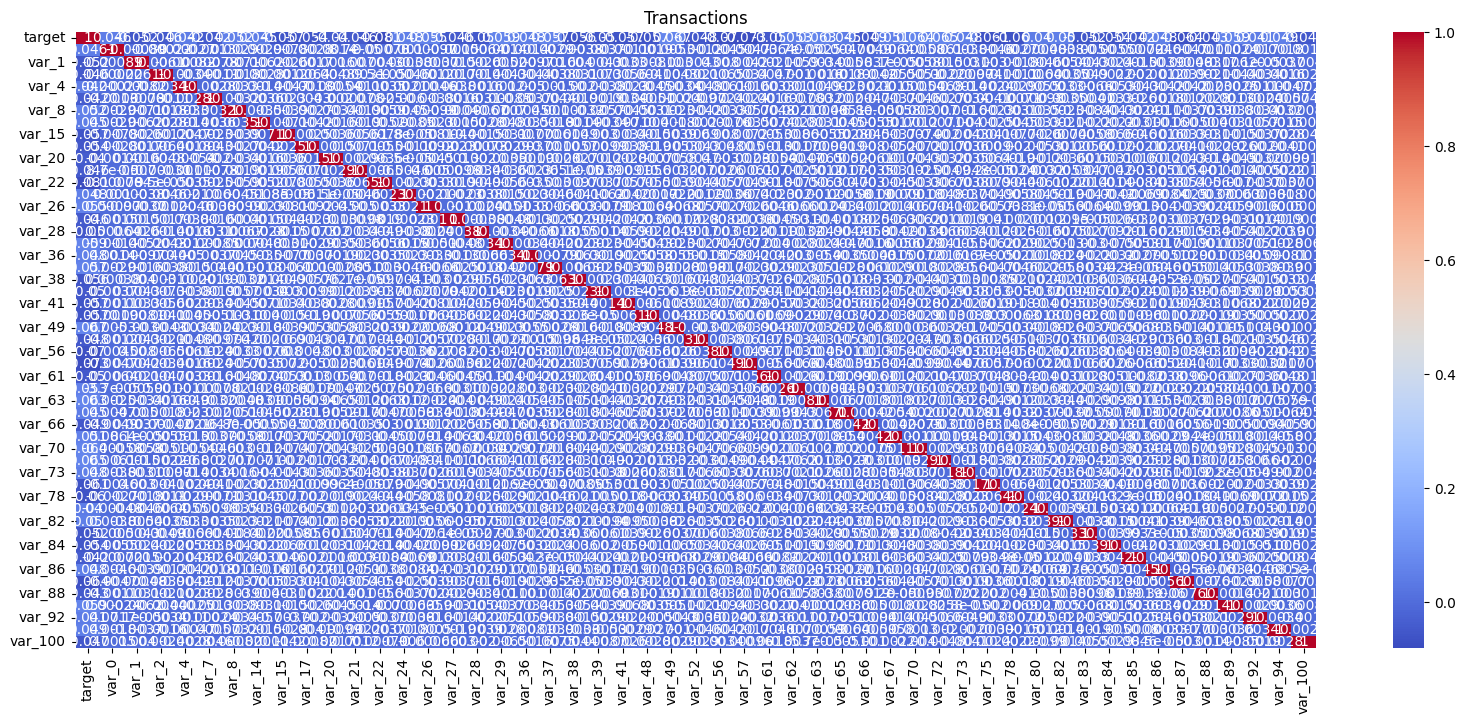

In [ ]:
plt.figure(figsize=(20,8))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title("Transactions")
plt.show()

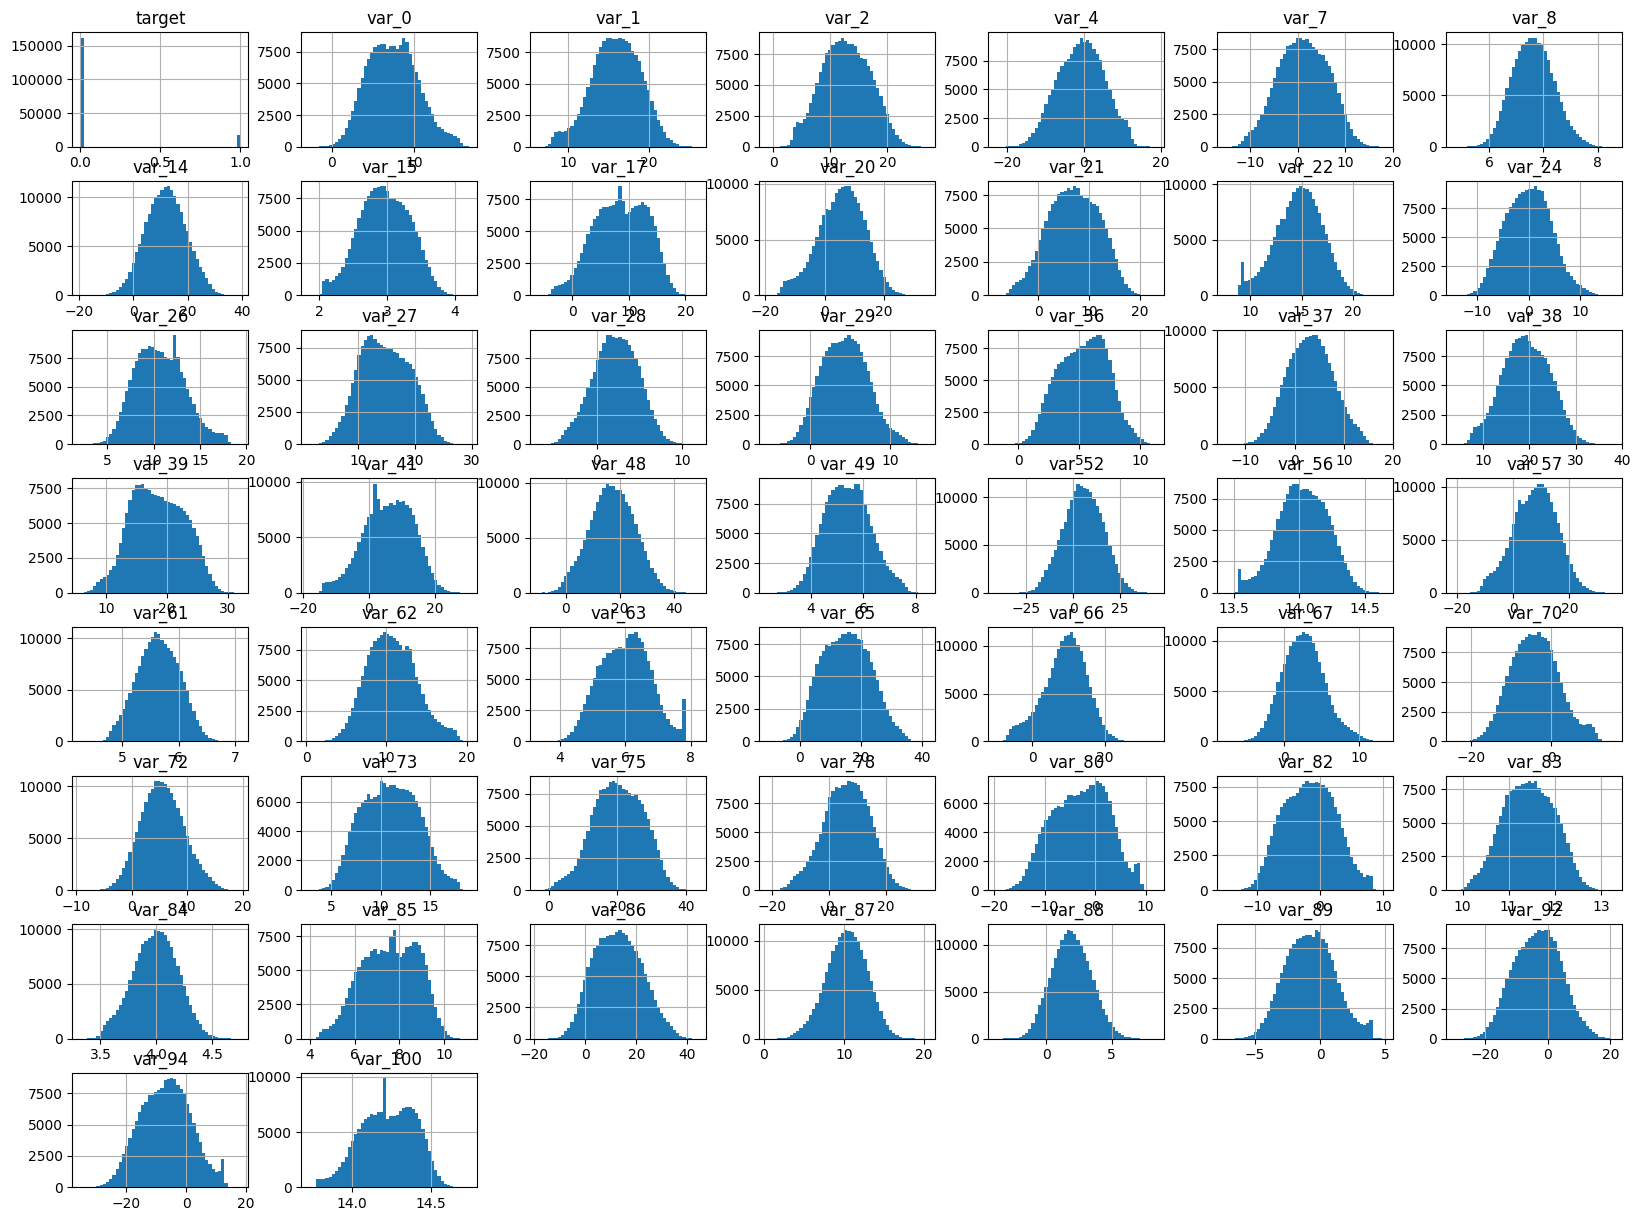

In [ ]:
df.hist(figsize=(20, 15), bins=50)
plt.show()

In [ ]:
df_success = df[df['target'] == 1].copy()
df_success

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
57,1.0,8.9078,12.1321,9.4707,-5.8102,0.4521,7.1264,15.6935,2.6980,4.3336,...,11.2059,4.0237,5.8905,12.4865,10.1419,2.3370,-3.1553,-12.6928,-3.0833,14.1895
125,1.0,6.2143,20.0990,23.5009,-0.8917,-3.9167,6.6863,21.4162,2.8672,6.4550,...,10.8110,3.9190,7.4971,35.7428,9.6149,2.2257,-0.5949,-9.4101,-15.6555,14.4514
151,1.0,8.9083,12.1117,18.0359,-4.9628,10.1135,6.8962,11.4553,2.6735,2.1990,...,11.6326,3.9193,5.0366,37.1453,17.0341,0.9987,-3.0163,-1.5409,-7.6389,14.1725
155,1.0,6.5612,13.9638,5.1980,12.1092,8.4874,6.4781,16.9541,2.0573,5.5008,...,11.2981,4.1316,7.2193,-1.8139,1.8190,2.5720,0.6780,6.4045,1.1754,14.1347
302,1.0,4.4616,9.7572,12.9317,7.6485,0.6382,5.8025,22.4577,3.0906,16.2501,...,11.5449,4.0001,9.0639,11.8805,9.4678,1.0561,-0.2107,9.8815,-2.9328,14.0933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049783,1.0,3.1286,15.0751,21.3962,11.3161,-10.0493,6.3525,25.4931,2.6605,7.2691,...,10.9172,4.1120,4.6540,9.1151,7.8918,2.5714,1.0304,5.2623,-0.6030,14.1993
1049818,1.0,15.2934,17.5721,5.8949,-4.0233,5.8840,7.3892,11.3932,2.7062,6.9666,...,11.1665,3.9652,7.4879,-7.9060,10.7256,0.8941,-3.5967,6.3976,0.5778,14.5067
1049978,1.0,7.4751,17.0314,5.0834,-1.5220,-2.4913,6.7953,10.7764,2.9049,2.6145,...,11.6605,3.6716,8.5965,19.2145,8.2747,4.0945,-3.0127,2.9477,-2.3696,14.4122
1049983,1.0,5.2746,14.4095,17.7709,-2.9855,-0.8515,6.5097,11.5599,2.9677,0.0507,...,11.8870,3.7776,6.9876,3.3482,9.7469,-0.3425,-2.5684,14.5286,-5.4146,14.4388


In [ ]:
df_fail = df[df['target'] == 0].copy()
df_fail

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049988,0.0,10.7453,13.3217,15.4001,4.0421,1.3116,6.3990,13.9387,2.9627,13.6450,...,11.6062,3.9162,9.7054,15.2405,10.6480,0.5372,0.4014,4.8258,-8.2380,14.0328
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


## Data Processing

10. Create two data frames: one with all the predictor columns (everything except for Unnamed: 0, ID_code and target) and one with just the target. Make sure they are copies and not slices.

1. Define a Gaussian Naïve Bayes model using Sklearn.

1. Divide the two data frames you created in step #10 into training and testing subsets.

1. Train the model using the training subset of the dataset.

1. Test the model using the testing subset of the dataset. Calculate and report the accuracy.

1. Perform a cross-validation loop to calculate the accuracy of your model. Report that accuracy. How does it compare to the accuracy you calculated in #14?

1. Plot a histogram of the accuracy scores you generated in your cross-validation loop. What do you notice about the distribution of accuracy scores?

1.  Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report). What do you notice?

1. The training data is very skewed towards non-successful transactions (about 90% of the training data has ‘target’==0). Remove enough non-successful transaction rows so that your remaining training data is 50%/50% split between successful and non-successful transactions. Hint: you can use the data frames you created in step #9.

1. Repeat the cross-validation process on this data set. Report what your cross-validation accuracy is in this 50/50 case.



In [ ]:
x = df.drop(columns=['target']).copy()
x

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,0.5878,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,6.5456,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,18.7893,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,1.1400,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,7.8002,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,3.1549,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,3.9661,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,3.8858,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,2.0014,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
y = df['target'].copy()
y

,target
3,0.0
5,0.0
11,0.0
15,0.0
19,0.0
...,...
1049990,0.0
1049993,0.0
1049995,1.0
1049997,0.0


In [ ]:
 ### model
model = GaussianNB()

In [ ]:
### TSS
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

In [ ]:
from sklearn.metrics import accuracy_score
### fit
model.fit(x_train,y_train)

### prediction
y_pred = model.predict(x_test)

### performance
#cv_accuracy = accuracy_score(y_test, y_pred) *100
#accuracy = 1-(y_test - y_pred).abs().mean()
cv_accuracy = accuracy_score(y_test, y_pred)*100
cv_accuracy

91.03611111111111

<Axes: >

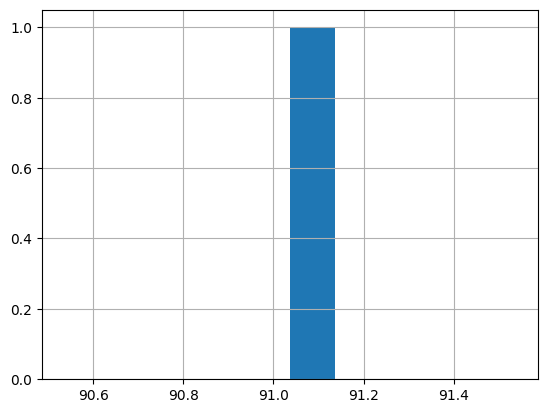

In [ ]:
pd.Series(cv_accuracy).hist()

## Data Visualization


20. Compare the results of your cross-validation with the whole training data and the reduced 50/50 training data

1. Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)




Text(0.5, 1.0, 'Transaction Confusion Metrix')

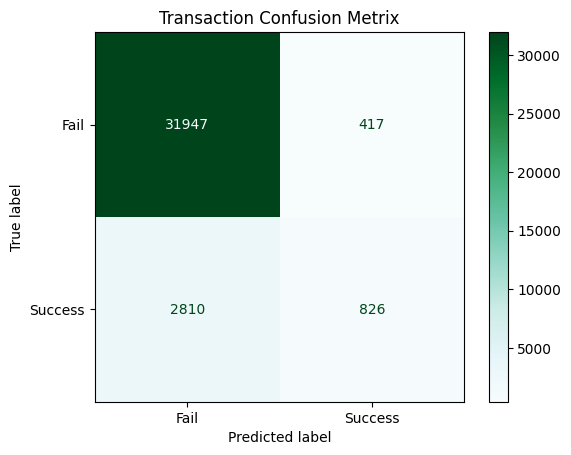

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

cm = ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred, normalize=None,display_labels=[ 'Fail','Success'],values_format ='d', cmap='BuGn'
)
cm.ax_.set_title("Transaction Confusion Metrix")

In [ ]:
print(classification_report(y_test,y_pred,target_names=["Fail","Success"]))

              precision    recall  f1-score   support

        Fail       0.92      0.99      0.95     32364
     Success       0.66      0.23      0.34      3636

    accuracy                           0.91     36000
   macro avg       0.79      0.61      0.65     36000
weighted avg       0.89      0.91      0.89     36000



In [ ]:
success_transactions = df[df["target"] == 1]
success_transactions.shape[0]

18040

In [ ]:
fail_transations = df[df["target"] == 0 ].sample(n = success_transactions.shape[0])
df_bal = pd.concat([fail_transations,success_transactions])
print(f"{len(success_transactions)},{len(fail_transations)}")

18040,18040


In [ ]:
df_bal.shape

(36080, 51)

In [ ]:
df_bal

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
610067,0.0,9.0656,12.7524,18.6529,0.5255,7.2255,7.1940,13.9894,3.2861,8.4567,...,11.7806,4.1267,8.5011,2.1017,7.4180,1.2381,0.5279,-1.4691,2.9074,14.1998
13520,0.0,5.5856,12.7405,12.4189,-8.0752,9.3467,6.1656,9.8267,2.9447,11.5478,...,11.8397,3.9395,8.4510,14.2654,6.9687,-2.0699,-1.8195,11.5520,-2.1828,14.1115
458364,0.0,12.4637,16.4303,12.2835,1.5619,-0.0408,7.0554,16.8100,3.4577,6.8435,...,12.3842,4.1700,7.0519,5.2161,13.7688,1.7574,2.2238,-5.8347,-3.0156,14.3194
849379,0.0,6.9030,18.3662,8.3514,-3.4308,5.1984,6.1164,9.2395,3.1663,3.3305,...,10.8926,4.2776,9.4224,21.5014,6.4308,2.6203,-1.1107,-0.4501,1.3331,14.3177
545165,0.0,9.4730,13.6438,10.6824,-9.3424,-4.2546,6.3478,16.4542,2.6081,8.1767,...,11.0520,3.8776,6.2677,25.4822,16.4378,4.9414,-2.0259,-5.9224,1.3482,14.0819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049783,1.0,3.1286,15.0751,21.3962,11.3161,-10.0493,6.3525,25.4931,2.6605,7.2691,...,10.9172,4.1120,4.6540,9.1151,7.8918,2.5714,1.0304,5.2623,-0.6030,14.1993
1049818,1.0,15.2934,17.5721,5.8949,-4.0233,5.8840,7.3892,11.3932,2.7062,6.9666,...,11.1665,3.9652,7.4879,-7.9060,10.7256,0.8941,-3.5967,6.3976,0.5778,14.5067
1049978,1.0,7.4751,17.0314,5.0834,-1.5220,-2.4913,6.7953,10.7764,2.9049,2.6145,...,11.6605,3.6716,8.5965,19.2145,8.2747,4.0945,-3.0127,2.9477,-2.3696,14.4122
1049983,1.0,5.2746,14.4095,17.7709,-2.9855,-0.8515,6.5097,11.5599,2.9677,0.0507,...,11.8870,3.7776,6.9876,3.3482,9.7469,-0.3425,-2.5684,14.5286,-5.4146,14.4388


In [ ]:
# from sklearn.model_selection import cross_val_score

# X_bal = df_bal.drop(columns=['target'])
# y_bal = df_bal['target']

# cv_accuracy_bal = cross_val_score(model, X_bal, y_bal, cv=5).mean()*100

# print("Balanced CV Accuracy:", cv_accuracy_bal.mean())

In [ ]:
from sklearn.metrics import accuracy_score
### fit
model.fit(X_bal,y_bal)

### prediction
y_bal_pred = model.predict(X_bal)

### performance
bal_accuracy = accuracy_score(y_bal, y_bal_pred)*100
bal_accuracy

75.71230598669622

In [ ]:
print(classification_report(y_bal,y_bal_pred,target_names=["Fail","Success"]))

              precision    recall  f1-score   support

        Fail       0.75      0.77      0.76     18040
     Success       0.76      0.75      0.75     18040

    accuracy                           0.76     36080
   macro avg       0.76      0.76      0.76     36080
weighted avg       0.76      0.76      0.76     36080



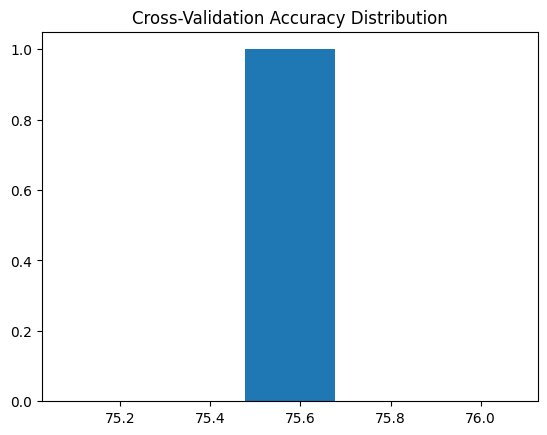

In [ ]:
plt.hist(cv_accuracy_bal, bins=5)
plt.title("Cross-Validation Accuracy Distribution")
plt.show()

In [ ]:
print(cv_accuracy)
print(cv_accuracy_bal)

91.03611111111111
75.57649667405765


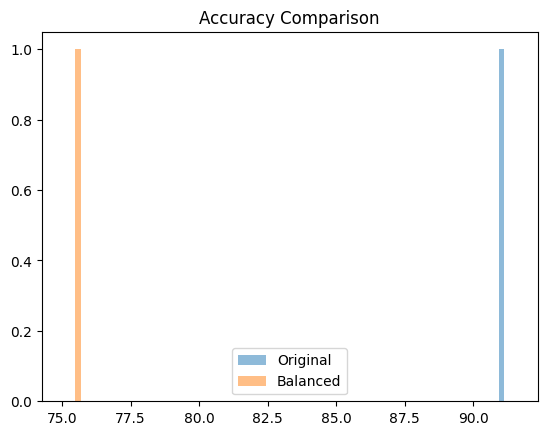

In [ ]:
plt.hist(cv_accuracy, bins=5, alpha=0.5, label='Original')
plt.hist(cv_accuracy_bal, bins=5, alpha=0.5, label='Balanced')
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

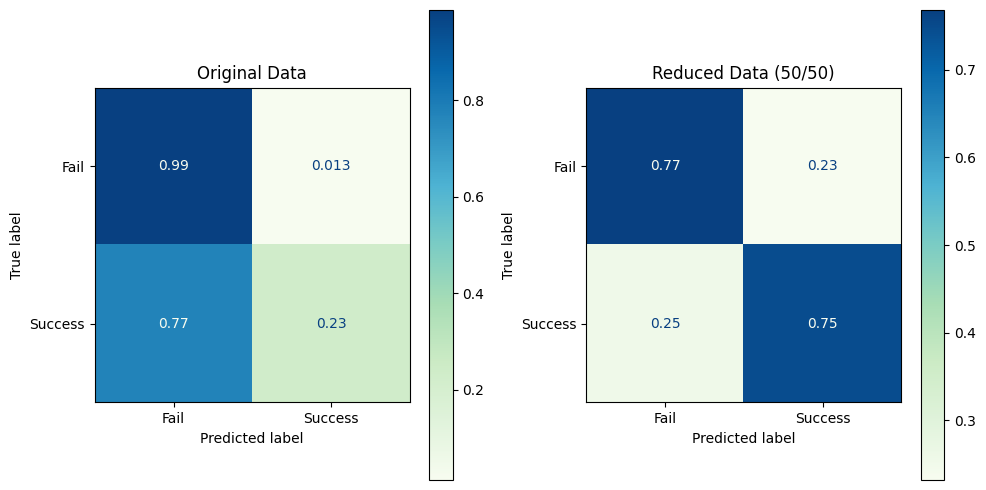

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        cmap="GnBu",
                                        normalize = "true",
                                        display_labels= ['Fail','Success'],
                                         ax=ax1
                                        )
ax1.set_title("Original Data")

ConfusionMatrixDisplay.from_predictions(y_bal, y_bal_pred, cmap="GnBu",
                                        normalize = "true",
                                        display_labels= ['Fail','Success'],
                                         ax=ax2
                                        )
ax2.set_title("Reduced Data (50/50)")

plt.tight_layout()

## Communicate the Results

22. Communicate the results of your analysis.



The Gaussian Naive Bayes model achieved a high cross-validation accuracy of 91% on the original dataset. However, this result is misleading due to the significant class imbalance, where approximately 90% of the observations correspond to unsuccessful transactions (target = 0). As a result, the model is biased toward predicting the majority class, leading to inflated accuracy but poor detection of successful transactions.

After balancing the dataset to a 50/50 distribution between successful and unsuccessful transactions, the cross-validation accuracy decreased to 75%. While this represents a drop in overall accuracy, it reflects a more realistic and meaningful evaluation of the model’s performance. The balanced model is better at identifying both classes, particularly the minority class (successful transactions), which is often of greater practical importance.

This comparison demonstrates that accuracy alone is not a sufficient metric for imbalanced classification problems. Addressing class imbalance leads to a more reliable model, even if it results in lower overall accuracy. Therefore, the balanced dataset provides a more trustworthy assessment of the model's predictive capability.

## Submit Final Project

23. Upload your finished Jupyter notebook to your Project 1 student folder.
